# 1.4.4 Smoothing Images

## Kernel Convolution

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [3]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [4]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [5]:
img

array([[0, 7, 0, 9, 6, 0, 3, 8, 3, 5, 8, 1],
       [9, 1, 3, 2, 6, 3, 9, 0, 8, 9, 6, 3],
       [9, 5, 5, 7, 9, 9, 3, 9, 1, 7, 0, 8],
       [9, 1, 4, 2, 5, 9, 8, 8, 6, 0, 2, 9],
       [2, 1, 8, 5, 8, 0, 0, 7, 4, 5, 5, 6],
       [8, 2, 7, 9, 5, 1, 5, 7, 2, 7, 6, 6],
       [9, 7, 6, 9, 8, 6, 9, 9, 1, 9, 2, 1],
       [8, 2, 7, 5, 8, 0, 5, 1, 6, 4, 4, 1],
       [1, 4, 2, 6, 7, 6, 3, 1, 2, 5, 5, 8],
       [9, 2, 0, 5, 6, 5, 0, 9, 3, 1, 1, 3],
       [4, 7, 7, 9, 5, 4, 1, 4, 7, 9, 9, 7],
       [7, 0, 5, 5, 5, 1, 4, 3, 0, 2, 4, 4]])

In [6]:
h,w=img.shape

In [7]:
print(h,w)

12 12


In [29]:
#[*range(-2,3)]

In [10]:
dst = np.zeros((h,w),dtype=int)

In [11]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [16]:
img

array([[169, 169, 168, ..., 175, 162, 138],
       [169, 169, 168, ..., 175, 162, 138],
       [169, 169, 168, ..., 175, 162, 138],
       ...,
       [ 53,  53,  59, ..., 115, 112, 114],
       [ 53,  53,  64, ..., 117, 118, 122],
       [ 53,  53,  64, ..., 117, 118, 122]], dtype=uint8)

In [17]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -20,   4, -17,   4, -12,  27, -34,  19,  10,   4,   0],
       [  0,   4,   1,  10,   9,  12, -23,  24, -26,  18, -23,   0],
       [  0, -15,   0, -13,  -8,  14,  12,   2,  11, -20,  -6,   0],
       [  0,  -9,  15,  -7,  17, -18, -20,   9,  -4,   4,   1,   0],
       [  0, -15,   3,  10,  -6, -12,   3,   5, -11,   6,   4,   0],
       [  0,   9,  -6,   8,   4,   6,  11,  18, -22,  22, -12,   0],
       [  0, -18,  13, -10,  12, -25,   7, -17,  16,  -8,   4,   0],
       [  0,   9,  -9,   5,   2,   9,   0, -11,  -7,   8,   2,   0],
       [  0, -12, -16,  -1,   2,   4, -18,  28,  -7, -14, -14,   0],
       [  0,  15,   7,  14,  -4,   4,  -8,  -4,  12,  17,  15,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [18]:
img = cv2.imread('lena.png', 0)

In [19]:
h,w=img.shape

In [20]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [ ]:
for i in range(l,h-l):   #ridge edge
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [22]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [32]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

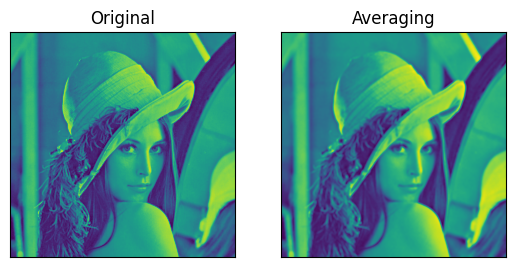

In [29]:
kernel=np.ones((5,5),np.float32)/25   #Box Blur
dst=cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]),plt.yticks([])
plt.show()

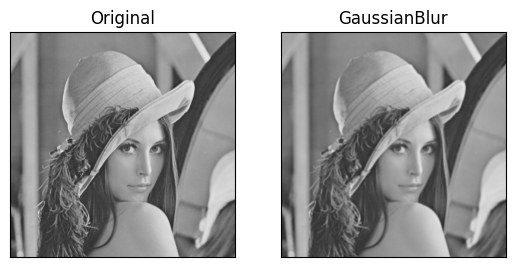

In [33]:
kernel=np.ones((5,5),np.float32)/25   #Box Blur
#dst=cv2.filter2D(img,-1,blur)
blur = cv2.GaussianBlur(img1,(5,5),0)
plt.subplot(121),plt.imshow(img1),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('GaussianBlur')
plt.xticks([]),plt.yticks([])
plt.show()

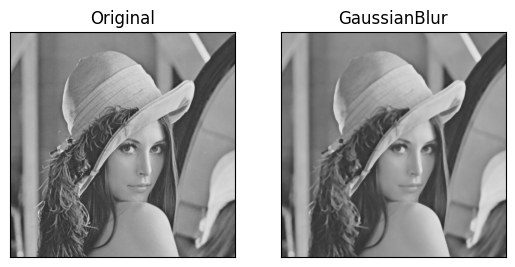

In [ ]:
kernel=np.ones((5,5),np.float32)/25   #Box Blur
#dst=cv2.filter2D(img,-1,blur)
blur = cv2.GaussianBlur(img1,(5,5),0)
median = cv2.medianBlur(img1,5)  #소팅해서 중앙값을 가져가는게 메디안
plt.subplot(121),plt.imshow(img1),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(median),plt.title('GaussianBlur')
plt.xticks([]),plt.yticks([])
plt.show()